# 1. Import Libraries

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

# 2. Import image dataset

In [3]:
data_dir = "EuroSAT"  

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

# 3. Transform image into tensor format

In [5]:
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

# 4. Load Datasets

In [7]:
train_dataset = datasets.ImageFolder(train_dir, transform=basic_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=basic_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

print("Classes:", class_names)

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


# 5. Device Setup

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# 6. Visualisation

## 6.1. Display image of all 10 clasees

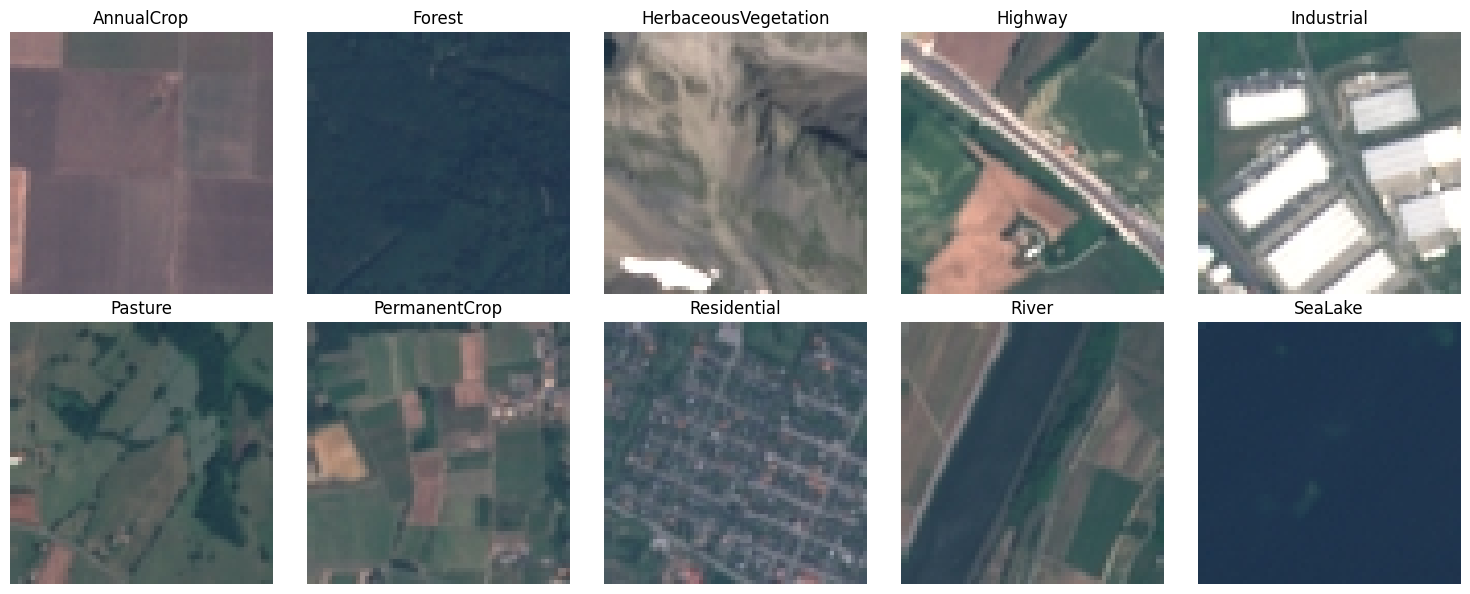

In [12]:
def show_one_per_class(dataset):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    class_seen = {}
    i = 0

    for img, label in dataset:
        if label not in class_seen:
            class_seen[label] = img

            # Convert CHW → HWC
            img_display = img.permute(1, 2, 0)

            axes[i].imshow(img_display)
            axes[i].set_title(dataset.classes[label])
            axes[i].axis("off")

            i += 1

        if len(class_seen) == len(dataset.classes):
            break

    plt.tight_layout()
    plt.show()

# Call function
show_one_per_class(train_dataset)

## 6.2. Visualise class distribution 

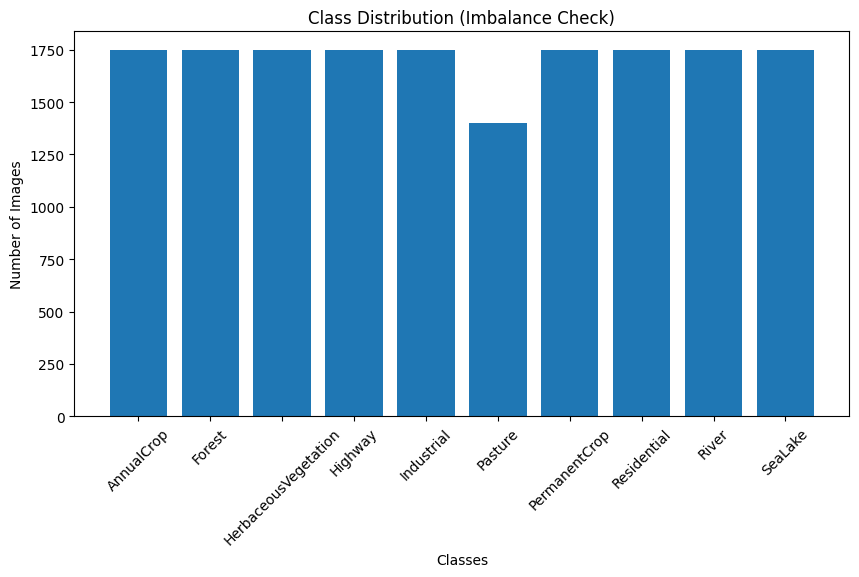

In [19]:
# Get labels
labels = [label for _, label in train_dataset]

# Count occurrences
class_counts = Counter(labels)

# Convert to readable format
counts = [class_counts[i] for i in range(len(class_names))]

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts)

plt.title("Class Distribution (Imbalance Check)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.show()

---
# 7. Baseline Model

## 7.1. Baseline Model

In [12]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()

        # Convolutional feature extractor
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),              # Activation function (introduces non-linearity)
            nn.MaxPool2d(2),        # Downsamples image by factor of 2 (reduces H and W)

            
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)         # Again reduces spatial size by factor of 2 (kernel, stride)
        )

        # Fully connected classifier
        self.fc = nn.Sequential(
            nn.Flatten(),  # Converts feature maps into 1D vector
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),

            # Output layer
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Pass input through convolutional layers
        x = self.conv(x)

        # Flatten and pass through fully connected layers
        x = self.fc(x)

        # Output logits (no softmax here; loss function will handle it)
        return x

In [ ]:
# First convolution layer:
# Input: 3 channels (RGB image)
# Output: 16 feature maps
# Kernel size: 3x3, padding keeps spatial size same

# Second convolution layer:
# Input: 16 channels → Output: 32 feature maps

# Fully connected layer:
# Input size = 32 feature maps * 16 * 16 spatial size
# (depends on input image size 64x64 → after 2 poolings → 16x16)

# Output layer:
# Produces probability logits for each class

## 7.2. Initialise Baseline Model

In [16]:
model = BaselineCNN(num_classes).to(device) 

## 7.3. Loss and Optimiser for Baseline Model

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 7.3. Train Baseline Model

In [20]:
train_losses = []
val_losses = []
val_accuracies = []
train_accuracies = []

epochs = 30
best_val_acc = 0.0   # Track best validation accuracy

print("Training Baseline Model....")

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Training accuracy
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    # Average training loss
    running_loss /= len(train_loader)
    train_losses.append(running_loss)

    train_acc = correct_train / total_train
    train_accuracies.append(train_acc)

    # Validation Phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # Average validation loss
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    accuracy = correct / total
    val_accuracies.append(accuracy)

    # Save best model
    if accuracy > best_val_acc:
        best_val_acc = accuracy
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': accuracy
        }, "best_baseline_model.pth")
        print("Best model saved!")

    # Print progress
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {running_loss:.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {accuracy:.4f}")

Training Baseline Model....
Epoch [1/30] Train Loss: 696.7270 Train Acc: 0.5072 Val Loss: 142.1501 Val Acc: 0.5717
Epoch [2/30] Train Loss: 489.4376 Train Acc: 0.6665 Val Loss: 131.3926 Val Acc: 0.5627
Epoch [3/30] Train Loss: 406.2985 Train Acc: 0.7279 Val Loss: 85.7736 Val Acc: 0.7363
Epoch [4/30] Train Loss: 354.4089 Train Acc: 0.7605 Val Loss: 74.8597 Val Acc: 0.7712
Epoch [5/30] Train Loss: 313.5273 Train Acc: 0.7886 Val Loss: 67.0694 Val Acc: 0.7913
Epoch [6/30] Train Loss: 278.6081 Train Acc: 0.8109 Val Loss: 68.3638 Val Acc: 0.7872
Epoch [7/30] Train Loss: 244.6561 Train Acc: 0.8340 Val Loss: 63.3832 Val Acc: 0.8093
Epoch [8/30] Train Loss: 223.9209 Train Acc: 0.8499 Val Loss: 74.2204 Val Acc: 0.7848
Epoch [9/30] Train Loss: 196.3345 Train Acc: 0.8706 Val Loss: 63.5234 Val Acc: 0.8158
Epoch [10/30] Train Loss: 174.7035 Train Acc: 0.8828 Val Loss: 61.7492 Val Acc: 0.8150
Epoch [11/30] Train Loss: 151.7280 Train Acc: 0.8974 Val Loss: 64.1094 Val Acc: 0.8163
Epoch [12/30] Train Lo

## 7.4. Evaluate Baseline Model

In [23]:
def evaluate(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       376
           1       0.94      0.93      0.93       376
           2       0.72      0.70      0.71       376
           3       0.63      0.63      0.63       375
           4       0.85      0.92      0.88       375
           5       0.75      0.82      0.78       300
           6       0.66      0.67      0.66       375
           7       0.92      0.91      0.91       376
           8       0.75      0.64      0.69       375
           9       0.97      0.94      0.96       376

    accuracy                           0.80      3680
   macro avg       0.80      0.80      0.80      3680
weighted avg       0.80      0.80      0.80      3680



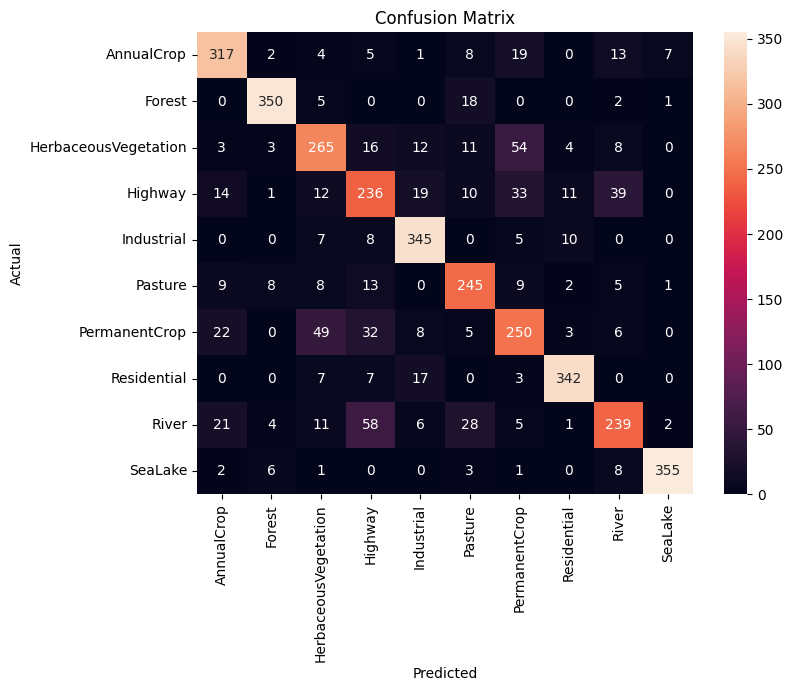

In [24]:
evaluate(model, test_loader, class_names)

## 7.5. Plot Loss Curve

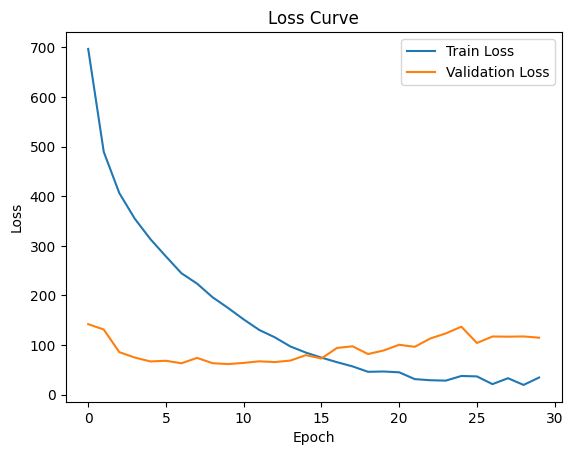

In [21]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 7.6. Plot Accuracy Curve

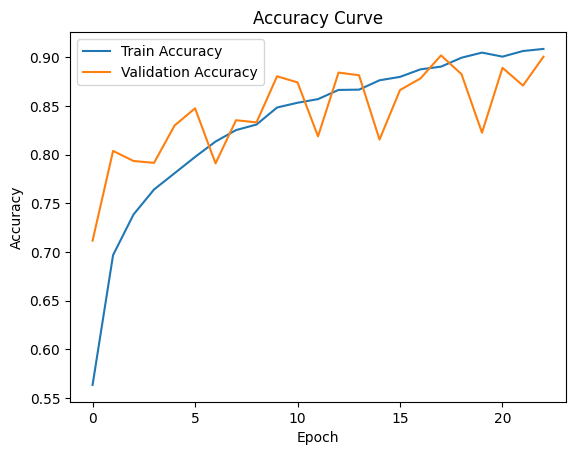

In [82]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
checkpoint = torch.load("best_baseline_model.pth", map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((64, 64)),  # since your images are 64x64
    transforms.ToTensor()
])

In [ ]:
class_names = train_dataset.classes

def predict_image_with_confidence(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)

        # Convert to probabilities
        probs = F.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probs, 1)

    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item() * 100

    return predicted_class, confidence_score


def show_prediction(image_path):
    image = Image.open(image_path)

    predicted_class, confidence = predict_image_with_confidence(image_path)

    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

show_prediction("/Users/natashababu/Documents/ComputerVision/coursework/EuroSAT/test/Highway/Highway_52.jpg")

---
# 8. Improved CNN Model

## 8.1. Transform and Load Model

In [66]:
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=aug_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

## 8.2. Initialise ImprovedCNN Model

In [68]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedCNN, self).__init__()

        # Feature extractor
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # NEW Block 3 (added depth)
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),

            # 64 channels, size becomes 8×8 after 3 pools
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),

            nn.Dropout(0.5),   # Prevent overfitting

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ImprovedCNN(num_classes).to(device)

## 8.3. Loss and Optimiser for Improved CNN Model

In [70]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)  # lower LR for stability

## 8.4. Train Improved CNN Model

In [72]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 30

best_acc = 0
patience = 5
counter = 0

print("Training Improved CNN Model....")

for epoch in range(epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    # Average training loss
    train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # Average validation loss
    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}")

    # Early Stopping + Best Model Saving
    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc
        }, "best_improved_model.pth")

        print("Best improved model saved!")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered.")
        break

Training Improved Model....
Epoch [1/30] Train Loss: 644.6239 Train Acc: 0.5633 Val Loss: 94.8644 Val Acc: 0.7116
Epoch [2/30] Train Loss: 464.4639 Train Acc: 0.6967 Val Loss: 66.2437 Val Acc: 0.8038
Epoch [3/30] Train Loss: 404.3319 Train Acc: 0.7385 Val Loss: 68.6101 Val Acc: 0.7935
Epoch [4/30] Train Loss: 369.7521 Train Acc: 0.7642 Val Loss: 69.0012 Val Acc: 0.7916
Epoch [5/30] Train Loss: 335.6558 Train Acc: 0.7809 Val Loss: 54.7199 Val Acc: 0.8299
Epoch [6/30] Train Loss: 314.6704 Train Acc: 0.7976 Val Loss: 49.7473 Val Acc: 0.8476
Epoch [7/30] Train Loss: 290.9509 Train Acc: 0.8135 Val Loss: 70.4163 Val Acc: 0.7910
Epoch [8/30] Train Loss: 274.9119 Train Acc: 0.8252 Val Loss: 54.3118 Val Acc: 0.8354
Epoch [9/30] Train Loss: 259.3599 Train Acc: 0.8310 Val Loss: 56.0503 Val Acc: 0.8332
Epoch [10/30] Train Loss: 238.6718 Train Acc: 0.8485 Val Loss: 40.1441 Val Acc: 0.8805
Epoch [11/30] Train Loss: 230.8273 Train Acc: 0.8534 Val Loss: 44.2183 Val Acc: 0.8743
Epoch [12/30] Train Loss

## 8.5. Evaluate Improved CNN Model

In [73]:
def evaluate(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       376
           1       0.97      0.91      0.94       376
           2       0.84      0.81      0.83       376
           3       0.89      0.84      0.87       375
           4       0.91      0.97      0.94       375
           5       0.81      0.96      0.88       300
           6       0.89      0.67      0.77       375
           7       0.96      0.98      0.97       376
           8       0.83      0.87      0.85       375
           9       0.95      0.98      0.96       376

    accuracy                           0.89      3680
   macro avg       0.89      0.89      0.89      3680
weighted avg       0.89      0.89      0.89      3680



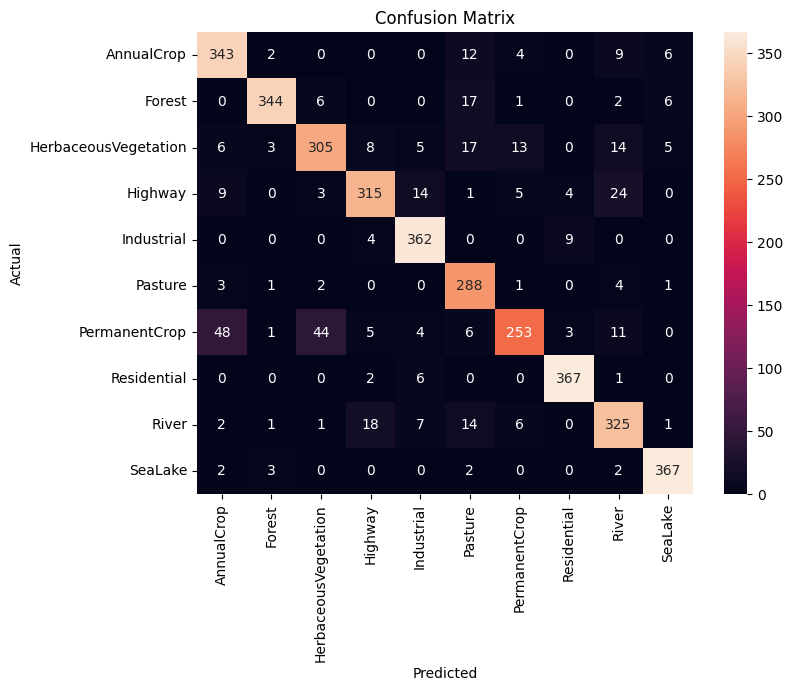

In [74]:
evaluate(model, test_loader, class_names)

## 8.6. Plot Loss Curve

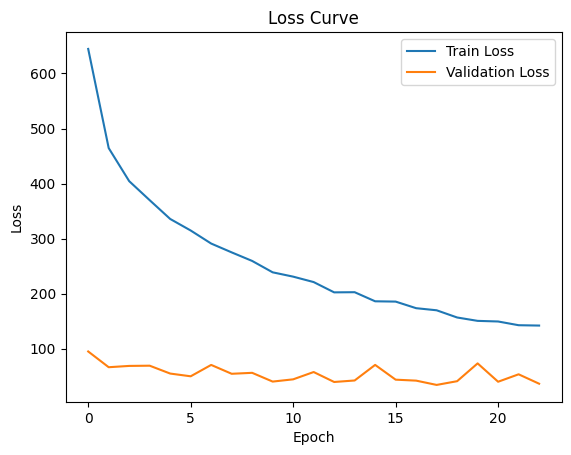

In [75]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 8.7. Plot Accuracy Curve

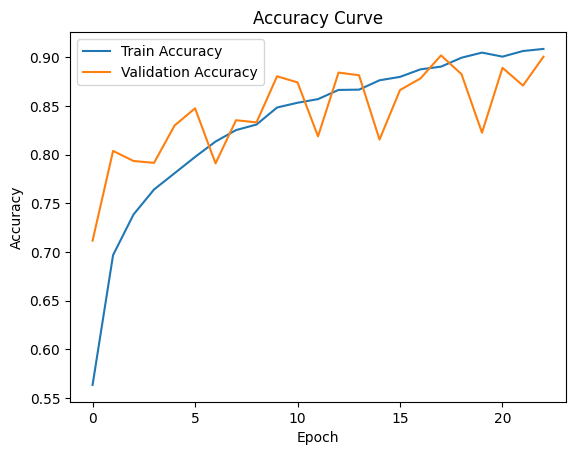

In [76]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
checkpoint = torch.load("best_improved_model.pth", map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

print("Model loaded successfully!")

In [ ]:
class_names = train_dataset.classes
print(class_names)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
class_names = train_dataset.classes

def predict_image_with_confidence(image_path):
    image = Image.open(image_path).convert("RGB")

    image = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image)

        # Convert logits to probabilities
        probs = F.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probs, 1)

    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item() * 100

    return predicted_class, confidence_score


In [ ]:
def show_prediction(image_path):
    image = Image.open(image_path)

    predicted_class, confidence = predict_image_with_confidence(image_path)

    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

show_prediction("/Users/natashababu/Documents/ComputerVision/coursework/EuroSAT/test/Highway/Highway_52.jpg")

---
# 9. Pre-Trained Model (ResNet18)

In [ ]:
imagenet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=imagenet_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=imagenet_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=imagenet_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
model = models.resnet18(pretrained=True)

# Freeze early layers
# for name, param in model.named_parameters():
#    if "layer4" not in name and "fc" not in name:
#       param.requires_grad = False


# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

## Loss & Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
# Only train final layer
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005)

## Training Setup

In [ ]:
epochs = 20
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_acc = 0

print("Training Pretrained ResNet18 Model...")

# Training Loop
for epoch in range(epochs):
    model.train()

    running_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = correct_train / total_train

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    train_losses.append(running_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {running_loss:.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "resnet18_best.pth")

## Load Best Model

In [ ]:
model.load_state_dict(torch.load("resnet18_best.pth"))
model.eval()

## Evaluate ResNet18 Model

In [ ]:
def evaluate(model, loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("ResNet18 Confusion Matrix")
    plt.show()

evaluate(model, test_loader, class_names)

## ResNet18 Model Loss Curve

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve - ResNet18")
plt.show()

## ResNet18 Model Accuracy Curve

In [ ]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve - ResNet18")
plt.show()

## Predict ReaNet18 Model

In [22]:
model = models.resnet18(pretrained=False)

# Replace final layer (MUST match training)
num_classes = len(class_names)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")

    # For display (original image)
    original_image = image.copy()

    # Transform for model
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probs = F.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probs, 1)

    class_name = class_names[predicted.item()]
    confidence = confidence.item() * 100

    return class_name, confidence, original_image

In [ ]:
def show_prediction(image_path):
    label, confidence, image = predict_image(image_path)

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {label} ({confidence:.2f}%)")
    plt.show()

    print(f"Predicted Class: {label}")
    print(f"Confidence: {confidence:.2f}%")

image_path = "/Users/natashababu/Documents/ComputerVision/coursework/EuroSAT/test/Highway/Highway_52.jpg"
show_prediction(image_path)

In [28]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model


In [30]:
def evaluate_model(model, test_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds))
    print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))


In [32]:
baseline_model = BaselineCNN(num_classes)
baseline_model = train_model(baseline_model, train_loader, val_loader)
evaluate_model(baseline_model, test_loader)


Epoch 1, Loss: 735.7764
Epoch 2, Loss: 503.3196
Epoch 3, Loss: 397.8429
Epoch 4, Loss: 347.8938
Epoch 5, Loss: 313.3968
Epoch 6, Loss: 289.9948
Epoch 7, Loss: 257.6921
Epoch 8, Loss: 239.3800
Epoch 9, Loss: 217.0878
Epoch 10, Loss: 197.3996
              precision    recall  f1-score   support

           0       0.72      0.89      0.80       376
           1       0.94      0.76      0.84       376
           2       0.67      0.77      0.72       376
           3       0.68      0.62      0.65       375
           4       0.91      0.93      0.92       375
           5       0.86      0.70      0.77       300
           6       0.72      0.61      0.66       375
           7       0.98      0.84      0.90       376
           8       0.73      0.78      0.76       375
           9       0.78      0.98      0.87       376

    accuracy                           0.79      3680
   macro avg       0.80      0.79      0.79      3680
weighted avg       0.80      0.79      0.79      3680

